## 1. Title + Paper you replicate + Research question

## 2. Data

### 2.1 Data Source

The data I'm using for this analysis come from the Integrated Public Use Microdata Series (IPUMS) Current Population Survey (CPS) and the Annual Social and Economic Supplements (ASEC). The CPS is a nationally representative household survey conducted by the U.S. Census Bureau, and the ASEC supplement provides detailed information on labor market outcomes, income, and demographic characteristics. Both datasets are suitable for my project in analyzing the labor supply effects of the 1986 Tax Reform Act.

### 2.2 Sample Construction

The sample is restricted to women aged 18 to 55, focusing on prime working-age individuals. Restricting the sample avoids the confounding effect from retirement or school enrollment and ensures comparability with the original Eissa(1996) Study

The final estimate sample contains 1,397,610 observations after applying the restriction



In [ ]:
import pandas as pd
import numpy as np

cols = [
    "YEAR",
    "AGE",
    "SEX",
    "MARST",
    "EMPSTAT",
    "INCWAGE",
    "EDUC",
    "NCHILD",
    "ASECWT"
]

df = pd.read_csv(
    "data/cps_00001.csv.gz",
    usecols=cols,
    compression="gzip"
)

df.head()

,YEAR,ASECWT,AGE,SEX,MARST,NCHILD,EMPSTAT,EDUC,INCWAGE
0,1984,568.47,43,1,1,1,10,40,16200.0
1,1984,568.47,41,2,1,1,10,72,9300.0
2,1984,616.15,20,1,6,0,10,72,7360.0
3,1984,568.47,42,1,1,1,10,72,18150.0
4,1984,568.47,41,2,1,1,31,72,0.0


In [ ]:
df.shape

(5831879, 9)

This tells us that in the data, there's 5,831,879 rows and 9 columns. However, as we're only measuring the labor supply of married women, our treated group will be marreid women which I'll restrict the sample to females that is age 18-55.

In [ ]:
# Keep only females
df = df[df["SEX"] == 2]

# Keep working age women
df = df[(df["AGE"] >= 18) & (df["AGE"] <= 55)]

df.shape

(1397610, 9)

This has shrink our data from 5,831,879 observations to only 1,397,610 observations now.

### 2.3 Variable Construction

The main outcome variable, employed, is an indicator equal to 1 if the individual is at work or has a job but is temporarily absent, and 0 otherwise. This follows the standard CPS employment classification and aligns with the labor supply measure used in the original paper.

The treatment indicator, treated, equals 1 for married women and 0 otherwise. Married women constitute the treatment group because the 1986 Tax Reform Act reduced marginal tax rates, affecting secondary earners in married households.

The post-treatment indicator, post, equals 1 for years 1987 and later, corresponding to the period after the reform was implemented.

The interaction between the treated and post will capture the Difference-in-Differences effect.

In [ ]:
df["post"] = (df["YEAR"] >= 1987).astype(int)
df["treated"] = (df["MARST"] == 1).astype(int)
df["employed"] = df["EMPSTAT"].isin([10, 12]).astype(int)
df = df[df["INCWAGE"] > 0]
df["log_wage"] = np.log(df["INCWAGE"])
df[["treated", "post", "employed"]].mean()

treated     0.570600
post        0.574483
employed    0.848697
dtype: float64

...

## 3. Identification (DiD assumptions + parallel trends)

### 3.1 Treatment and Control Groups

The identification strategy had exploits the differential impact of the 1986 Tax Reform Act on married versus single women. The reform had reduced marginal tax rates in a way that primarily affected secondary earners in married households, and as married women are more likely to be secondary earners, they experienced a larger change in the labor supply incentives.

Married women therefore constitute the treatment groups, while single women serve as the control group. The post treatment begin in 1987 follow by the implementation of the tax reform.

The Difference in Differences framework compares the change in employment outcomes for married women before and after the reform to the corresponding change for single women over the same period as well.

### 3.2 Parallel Trends Assumption

The key identifying assumption of the Difference-in-Differences design is the parallel trends assumption. In the absence of tax reform, the employment trends for married and single women have followed a similar trajectory over time.

Under this assumption, any change in employment between married and single women after 1987 can be attributed to the reform rather than to other confounding factors.

To assess the plausibility of this assumption, I examined pre-reform employment trends for both groups. If employment rates move in parallel before 1987, this provides support for the identification strategy.

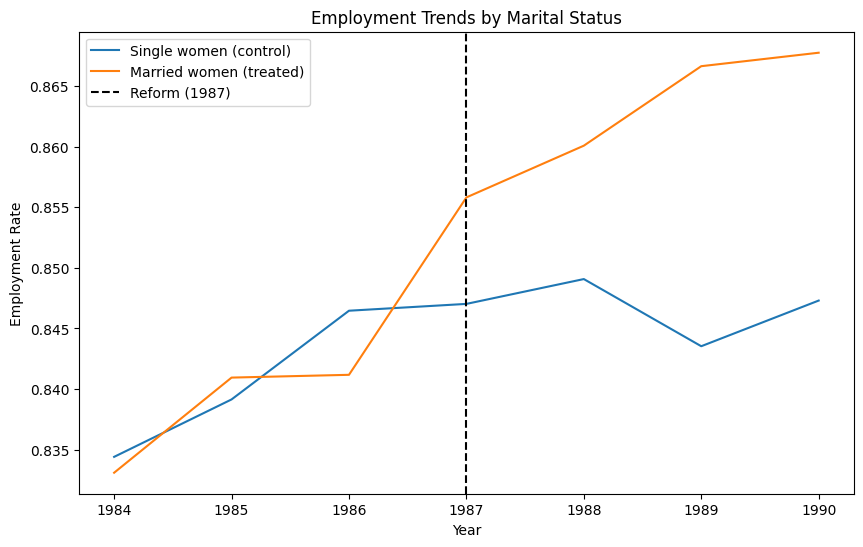

In [ ]:
group_means = (
    df.groupby(["YEAR", "treated"])["employed"]
      .mean()
      .reset_index()
)

pivot = group_means.pivot(index="YEAR", columns="treated", values="employed")

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(pivot.index, pivot[0], label="Single women (control)")
plt.plot(pivot.index, pivot[1], label="Married women (treated)")
plt.axvline(1987, color="black", linestyle="--", label="Reform (1987)")

plt.xlabel("Year")
plt.ylabel("Employment Rate")
plt.title("Employment Trends by Marital Status")
plt.legend()
plt.show()

This figure plots the average employment rates for married women (Treated group) and the single women (Control group) from 1984 to 1990. The vertical dashed line indicates the implementation of the 1986 Tax Reform Act, which we treat as occurring in 1987.

Before the reform, employment trends for married and single women appeared similar. While both groups experience a modest increase in employment level, there is no clear evidence of diverging trends before the policy change. Although the levels differ slightly across years, the overall pre-reform trajectories move in parallel.

After 1987, employment among married women increased more sharply than among single women. The gap between the two groups had widened in the post-reform period, consistent with the hypothesis that lower marginal tax rates will increase labor incentives for married women.

The similarity in pre-reform trends provided visual support for the parallel trends assumption underlying the Difference-in-Differences strategy. While this plot does not prove the assumption holds exactly, it suggests that in the absence of the tax reform, the employment trends between married and single women would have evolved similarly

### 3.3 Interpretation of the DiD Estimator

The Difference-in-Differences estimator is captured by the interaction between the treatment indicator and the post-reform indicator. This interaction term measures the additional change in employment among married women after the reform, relative to single women.

Under the parallel trends assumption, the coefficient on the interaction term will identify the causal effect of the tax reform on married women's employment.



## 4. Empirical Strategy (equation + variables)

We will estimate the impact of the 1986 Tax Reform Act (Implemented beginning in 1987 in our data coding) on women's employment using a Difference-in-Differences design. The key comparison is between married women and single women before and after the reform.



In [ ]:
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# -----------------------------
# 4.0 Quick sanity checks
# -----------------------------
# Make sure required columns exist
needed = ["YEAR", "AGE", "EDUC", "NCHILD", "ASECWT", "treated", "post", "employed"]
missing = [c for c in needed if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in df: {missing}")

# Restrict to analysis years used in the plot (optional but recommended for consistency)
df = df[(df["YEAR"] >= 1984) & (df["YEAR"] <= 1990)].copy()

# Drop missing / invalid covariates (light cleaning)
for c in ["AGE", "EDUC", "NCHILD", "ASECWT"]:
    df = df[df[c].notna()]

# Some CPS codes can be weird; keep plausible ranges
df = df[(df["AGE"] >= 18) & (df["AGE"] <= 55)].copy()
df = df[df["ASECWT"] > 0].copy()

def did_summary_table(models, names):
    rows = []
    for m, nm in zip(models, names):
        coef = m.params.get("treated:post", np.nan)
        se   = m.bse.get("treated:post", np.nan)
        pval = m.pvalues.get("treated:post", np.nan)
        n    = int(m.nobs)
        rows.append([nm, coef, se, pval, n])
    out = pd.DataFrame(rows, columns=["Model", "DiD (treated×post)", "SE", "p-value", "N"])
    return out

Before we estimate the model, we will perform some consistency checks and data cleaning.

First, we will ensure that all required variables for this analysis are present in the dataset, including demographic characteristics, treatment indicators, and employment status. Then we restrict the sample to the years 1984 - 1990 to match the period used in the graphical analysis.

Next, observations with missing values in the key covariates are removed. We further restrict the sample to working-age women and exclude observations with non-positive sampling weights. The restriction will ensure that the estimate is internally consistent and aligns with the labor supply population of interest.

Lastly, we define a function to construct a clean summary table of the DiD coefficient across the model specifications. This function extracts the interaction term coefficient (treated x post), its standard error, p-value, and sample size, facilitating the comparison across increasingly rich models.

### 4.1 Baseline DiD Model

Difference-in-Difference Specification:
We estimate the following DiD regression: 

$ Employment_{it} = \beta_0 + \beta_1 Treated_i + \beta_2 Post_t + \beta_3 (Treated_i \times Post_t) + \epsilon_{it} $

Where:
- $ Employment_{it}$ is an inidicator equal to 1 if the woman is employed, 0 otherwise
- $ Treated_{i} $ = 1 if the woman is married; 0 if single
- $ Post_t $ = 1 for years 1987 and later; 0 for years 1986 and earlier 
- $ \beta_3 $ is the DiD estimand: the differential change in employment for married women after the reform relative to single women

As employment is binary, we estimate the model as a linear probability model using OLS. Coefficients are interpreted as percentage point change in employment

### 4.2 Controls and Year Fixed Effects

To improve the precision and reduce bias from compositional change in the observed characteristics across the time and groups, we will be estimating an augmented specification:

$ Employment_{it} = \beta_3 (Treated_i \times Post_t) +X'_{it}\theta +\gamma_t+\epsilon_{it} $

where $ X'_{it} $ is includes the key observable covariates (age, education, number of children) and $\gamma_t$ denotes year fixed effects to capture the common macro trends.

### 4.3 Survey Weights and Standard Errors

In this project, we will estimate the regression using the CPS ASEC survey weights to ensure the results are representative of the national population. Throughout the project, standard errors are reported as heteroskedasticity-robust (HC1), and as a robustness check, we will also be computing standard errors clustered by year to allow for common shocks within each year; however, as the number of years is limited, inference from year cluster standard errors will be interpreted cautiously.

### 4.4 Dynamic DiD (Event Study)

To assess the pre trends and the evolution of treatment effect, we will estimate an event study specification:

$$
Employment_{it}
=
\sum_{k \ne -1}
\delta_k \left( Treated_i \times \mathbf{1}[t = k] \right)
+ X'_{it}\theta
+ \gamma_t
+ \varepsilon_{it}
$$

where year 1986 is the omitted reference period where (k = -1) The coefficient  $\delta_k$ show whether treated and control group were trending similarly pre-reform and how effects evolve after the reform.

## 5. Results (Main Tables/Figures)

#### Main DiD Results

In [ ]:
import statsmodels.formula.api as smf

model = smf.ols(
    "employed ~ treated + post + treated:post",
    data=df
).fit(cov_type="HC1")

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               employed   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     58.46
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           9.06e-38
Time:                        19:51:00   Log-Likelihood:                -83434.
No. Observations:              212692   AIC:                         1.669e+05
Df Residuals:                  212688   BIC:                         1.669e+05
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.8401      0.002    451.248   

The coefficient on the interaction term "treated:post" is 0.01747 and is statistically significant at the conventional levels(p<0.01>).

This implies that after the 1986 Ta Reform Act, married women's employment has increased by approximately 1.74 percentage points relative to single women.

The positive and statistically significant estimate is consistent with the hypothesis that reduction in marginal tax rate had increase the labor supplied incentives for married women.

The magnitude is economically meaningful, though smaller than some estimates reported in the original Eissa(1996) paper. However, thses difference may happen from sample construction, weighting, or even specification differents.

## 6. Robustness Checks

## 7. Conclusion

## 8. References
